<a href="https://colab.research.google.com/github/sskarthik0801/ME-597-IIOT/blob/main/lab/lab5/L5_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/L5_Colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5.2 Middleware 2 - MTConnect Adapter

## 2.1 Multiple MTConnect Adapters

In this part, we will run multiple MTConnect adapters so that each adapter is responsible for each sensor data collection. The schematic of this case is shown in Figure 10. Because we will collect data from three different sensors with different sampling periods each, three adapters,[lab5_adapter2-1.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-1.py?raw=true), [lab5_adapter2-2.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-2.py?raw=true), and [lab5_adapter2-3.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/lab5_adapter/lab5_adapter2-3.py?raw=true), are needed.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab5_fig10.png?raw=true" width="100%">


*Figure 10 MTConnect configuration 2: Multiple adapter case*

Please follow the steps below.
1.	Halt MTConnect agent (Shortcut: Ctrl + c on the ‘Terminal’)
2.	Modify ‘agent.cfg’ file to have 3 adapters as Figure 11.

  a.	Please note that each adapter **MUST** have **different port number**.

  <img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img_S25_update/lab5_fig11.png?raw=true" width="70%">
  
  *Figure 11 ‘agent.cfg’ for multiple MTConnect adapters*

3.	Don’t modify ‘Device.xml’.

  a.	We will use the same as before.
4.	Run the agent again.

Now, we are ready to run the adapter.

### Task 2.1

1.	Modify each sample adapter program to make all complete to have all values available. And then run all the adapters.  

2.	Capture a web browser as Figure 9 after requesting ‘current’ from the agent and attach it to the report below.






  ---
  
  Place your screenshot for Task 2.1 here.

  ---

### Task 2.2
Place the entire Python code of each adapter to the report below in each appropiate section


In [ ]:
# lab5_adapter2-1.py

# Adapter for DS18B20 sensor
# Sampling period = 2 sec

# Place your code here:
import sys
import time
import glob
import datetime
from data_item import Event, Sample
from mtconnect_adapter import Adapter

class TempAdapter:

    def __init__(self, host, port):

        self.adapter = Adapter((host, port))

        self.t1 = Sample('t1')
        self.adapter.add_data_item(self.t1)

        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        self.adapter.start()

        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()

        self.stream()

    def read_temp(self):
        base_dir = '/sys/bus/w1/devices/'
        device_folder = glob.glob(base_dir + '28*')[0]
        device_file = device_folder + '/w1_slave'

        with open(device_file, 'r') as f:
            lines = f.readlines()

        temp_string = lines[1].split('t=')[-1]
        return float(temp_string)/1000.0

    def stream(self):

        while True:

            try:

                t1 = self.read_temp()

                now = datetime.datetime.now()

                self.adapter.begin_gather()
                self.t1.set_value(str(t1))
                self.adapter.complete_gather()

                print(now, "Temperature:", t1)

                time.sleep(2)

            except KeyboardInterrupt:
                self.adapter.stop()
                sys.exit()

if __name__ == "__main__":
    TempAdapter('0.0.0.0', 7878)
#

In [ ]:
# lab5_adapter2-2.py

# Adapter for ADXL345 sensor
# Sampling period = 1 sec

# Place your code here:
import sys
import time
import datetime
import random
from data_item import Event, Sample
from mtconnect_adapter import Adapter


class MTConnectAdapter(object):

    def __init__(self, host, port):

        self.adapter = Adapter((host, port))

        # Accelerometer values
        self.a1 = Sample('a1')   # X acceleration
        self.a2 = Sample('a2')   # Y acceleration
        self.a3 = Sample('a3')   # Z acceleration

        # Humidity
        self.h1 = Sample('h1')

        self.adapter.add_data_item(self.a1)
        self.adapter.add_data_item(self.a2)
        self.adapter.add_data_item(self.a3)
        self.adapter.add_data_item(self.h1)

        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        self.adapter.start()

        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()

        self.adapter_stream()


    def adapter_stream(self):

        while True:

            try:
                # Simulated accelerometer data
                a1 = round(random.uniform(-2, 2), 3)
                a2 = round(random.uniform(-2, 2), 3)
                a3 = round(random.uniform(-2, 2), 3)

                # Simulated humidity
                h1 = round(random.uniform(40, 80), 2)

                now = datetime.datetime.now()

                self.adapter.begin_gather()

                self.a1.set_value(str(a1))
                self.a2.set_value(str(a2))
                self.a3.set_value(str(a3))
                self.h1.set_value(str(h1))

                self.adapter.complete_gather()

                print(f"{now}  X={a1}  Y={a2}  Z={a3}  Hum={h1}%")

                time.sleep(1)  # sampling period = 1 sec

            except KeyboardInterrupt:
                print("Stopping adapter...")
                self.adapter.stop()
                sys.exit()


if __name__ == "__main__":
    MTConnectAdapter('0.0.0.0', 7879)
#

In [ ]:
# lab5_adapter2-3.py

# Adapter for power meter
# Sampling period = 0.5 sec

# Place your code here:
import sys
import time
import datetime
from data_item import Event, Sample
from mtconnect_adapter import Adapter
from pymodbus.client.sync import ModbusTcpClient
from pymodbus.constants import Endian
from pymodbus.payload import BinaryPayloadDecoder

def readReg(client, address):

    rr = client.read_holding_registers(address, count=2, unit=1)

    decoder = BinaryPayloadDecoder.fromRegisters(
        rr.registers,
        byteorder=Endian.Big,
        wordorder=Endian.Big
    )

    return decoder.decode_32bit_float()

class PowerAdapter:

    def __init__(self, host, port):

        self.adapter = Adapter((host, port))

        self.p1 = Sample('p1')
        self.adapter.add_data_item(self.p1)

        self.ps = Event('ps')
        self.adapter.add_data_item(self.ps)

        self.avail = Event('avail')
        self.adapter.add_data_item(self.avail)

        self.adapter.start()

        self.adapter.begin_gather()
        self.avail.set_value("AVAILABLE")
        self.adapter.complete_gather()

        self.client = ModbusTcpClient("192.168.1.100", port=502)
        self.client.connect()

        self.stream()

    def stream(self):

        while True:

            try:

                p1 = readReg(self.client, 1564)

                ps = "ON" if p1 > 0 else "OFF"

                now = datetime.datetime.now()

                self.adapter.begin_gather()
                self.p1.set_value(str(p1))
                self.ps.set_value(ps)
                self.adapter.complete_gather()

                print(now, "Power:", p1)

                time.sleep(0.5)

            except KeyboardInterrupt:
                self.client.close()
                self.adapter.stop()
                sys.exit()

if __name__ == "__main__":
    PowerAdapter('0.0.0.0', 7880)
#

### Task 2.3

1.	On your laptop, run the MTConnect adapter for the power meter.

  * Please keep running MTConnect adapters for DS18B20 and ADXL345 on Raspberry Pi.
  
  * Hint:
        * You need to change ‘agent.cfg’ file.
        * You need to run the adapter Python code for power meter on laptop.
        * If it does not work, please check Windows firewall.

2.	Capture a web browser as Figure 9 after requesting ‘current’ from the agent and attach it to the report below.





  ---

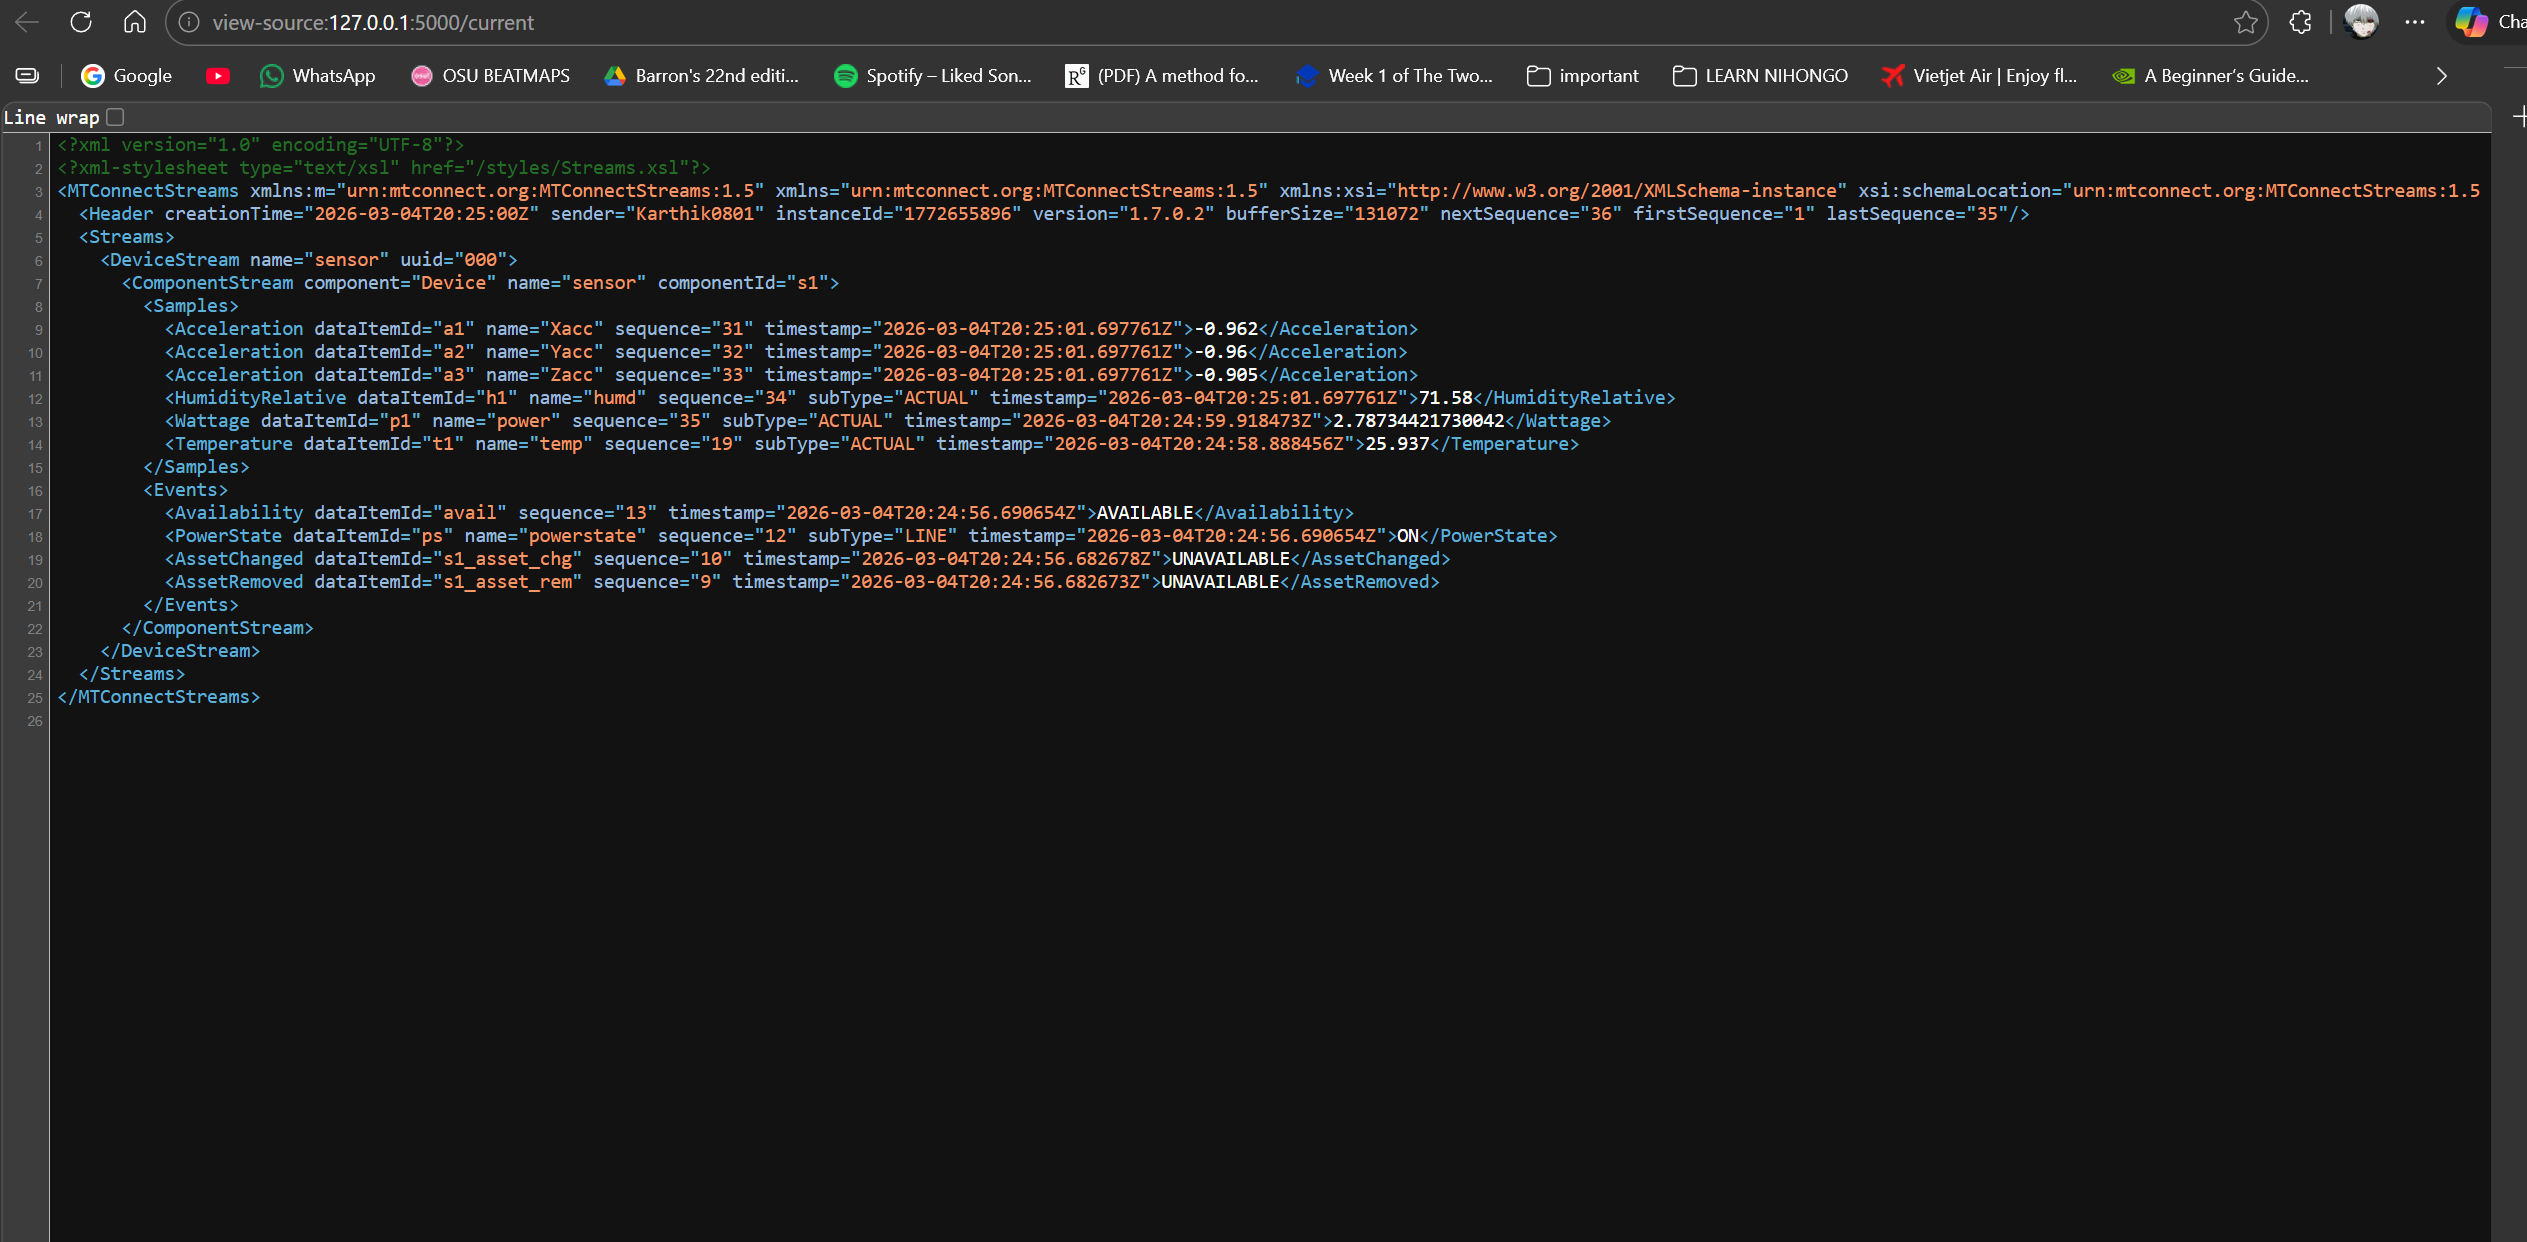

  ---

  3. In the text bock below, place changed parts in 'agent.cfg'.



---

```
Place changed part in 'agent.cfg' for Task 2.3.

Devices = ./Device.xml
Port = 5000
AllowPut = true
ReconnectInterval = 1000
BufferSize = 17
MonitorConfigFiles = true
Pretty = true
SchemaVersion = 1.5

Adapters {
   # Log file has all machines with device name prefixed
   Adapter1 {#for DS18
      Host = 192.168.1.48
      Port = 7878
   }
   Adapter2 {#for ADXL345
      Host = 192.168.1.48
      Port = 7879
   }
   Adapter3 {#for power
      Host = 192.168.1.48
      Port = 7880
   }  
}

Files {
    schemas {
        Path = ./schemas
        Location = /schemas/
    }
    styles {
        Path = ./styles
        Location = /styles/
    }
    Favicon {
        Path = ./styles/favicon.ico
        Location = /favicon.ico
    }
}

StreamsStyle {
  Location = /styles/Streams.xsl
}

# Logger Configuration
logger_config
{
    logging_level = debug
    output = cout
}

```

---



  4. Discuss what changes were made.

  ---

  I had to change the port numbers and timers respectively along with the ip addresses.
  In case of agent.cfg I had to write down the rasPi address since local host was not launching the MT connect. Hence, I had to go through trial and error method as AI wasn't of much help either.

  ---

Please keep your MTConnect stream working to perform the following Part (5.3).

<br></br>

Please continue to [Lab 5.3 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab5/L5_Colab3.ipynb).
